# Ejercicio 1b: puntos singulares, linealización y retrato de fases

*(Traducción a Python de `ejercicio1b.m` + `ej1b.m`)*

$$\dot x_1 = x_2 - x_1|x_1|, \qquad \dot x_2 = 1-x_1$$

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Función de estado (equivalente a `ej1b.m`)

In [2]:
def ej1b(t, x):
    """Ecuaciones de estado del sistema del ejercicio 1b."""
    x1, x2 = x
    return [x2 - x1*abs(x1), 1 - x1]

## Puntos singulares y linealización

**Nota:** `sympy` sí sabe derivar $|x_1|$ (usando la función `sign`), pero ten en cuenta que $|x_1|$ no es diferenciable en $x_1=0$ — no supone problema aquí porque, como veremos, el único punto de equilibrio no cae en $x_1=0$.

In [3]:
x1, x2, s = sp.symbols('x1 x2 s', real=True)

f = sp.Matrix([
    x2 - x1*sp.Abs(x1),
    1 - x1
])
f

⎡-x₁⋅│x₁│ + x₂⎤
⎢             ⎥
⎣   1 - x₁    ⎦

In [4]:
J = f.jacobian([x1, x2])
J

⎡-x₁⋅sign(x₁) - │x₁│  1⎤
⎢                      ⎥
⎣        -1           0⎦

In [5]:
soluciones = sp.solve(f, [x1, x2], dict=True)
soluciones

In [6]:
for punto in soluciones:
    print('Punto de equilibrio:', punto)

    Je_sym = J.subs(punto)
    print('Je =')
    display(Je_sym)

    Je_num = np.array(Je_sym.evalf(), dtype=complex)
    E = np.linalg.eigvals(Je_num)
    print('autovalores:', E)

    D = (s*sp.eye(2) - Je_sym).det()
    print('polinomio caracteristico:', sp.expand(D))
    print()

Punto de equilibrio: {x1: 1, x2: 1}
Je =


⎡-2  1⎤
⎢     ⎥
⎣-1  0⎦

autovalores: [-1.+0.j -1.-0.j]
polinomio caracteristico: s**2 + 2*s + 1



El único punto de equilibrio es $(1,1)$, con autovalores reales negativos repetidos (nodo estable).

## Retrato de fases

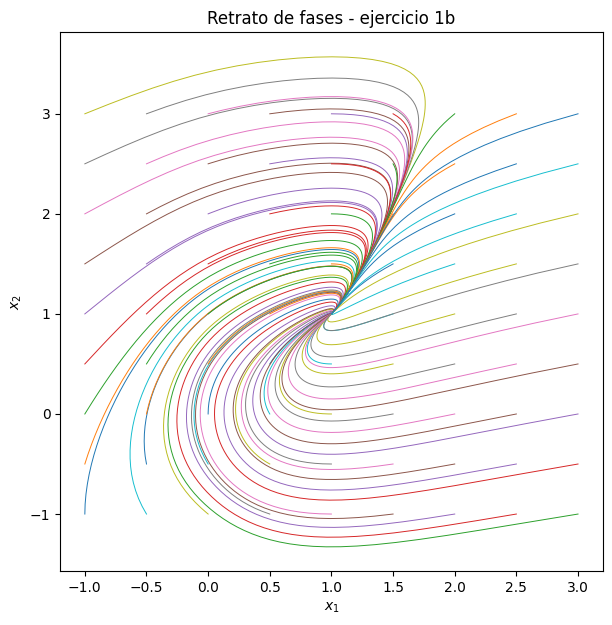

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

for i in np.arange(-1, 3.001, 0.5):
    for j in np.arange(-1, 3.001, 0.5):
        sol = solve_ivp(ej1b, [0, 50], [i, j], max_step=0.05)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Retrato de fases - ejercicio 1b')
plt.show()